CLUSTERING ANALYSIS 

Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, 
and provide hands-on experience in applying these techniques to a real-world dataset.

Datasets :

Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_excel(r"C:\Users\ACRE\Downloads\EastWestAirlines (1).xlsx",sheet_name=1)

In [4]:
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [7]:
df.shape

(3999, 12)

In [8]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [9]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [10]:
df[df.duplicated()]

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?


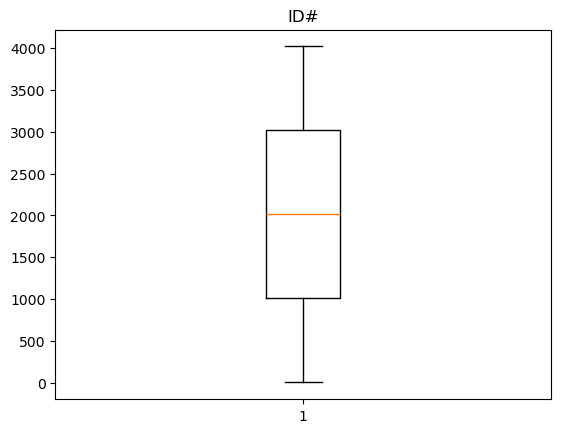

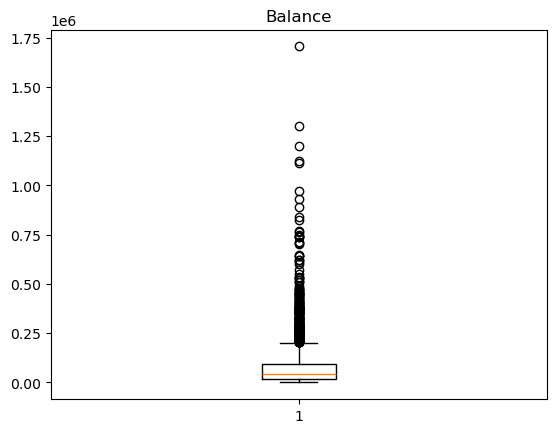

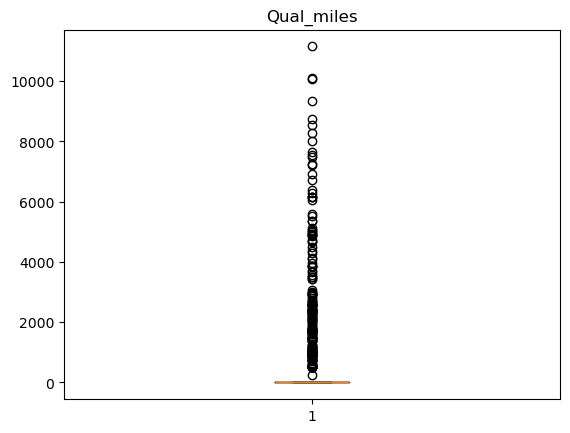

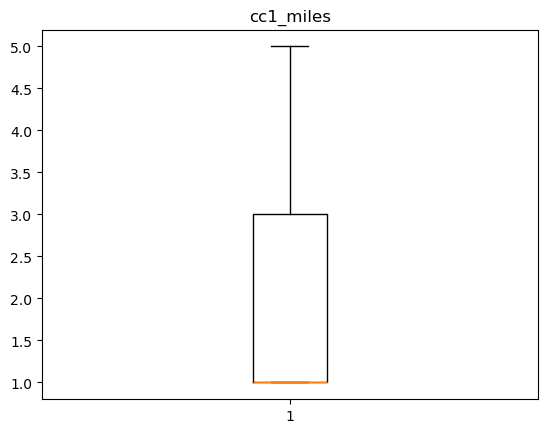

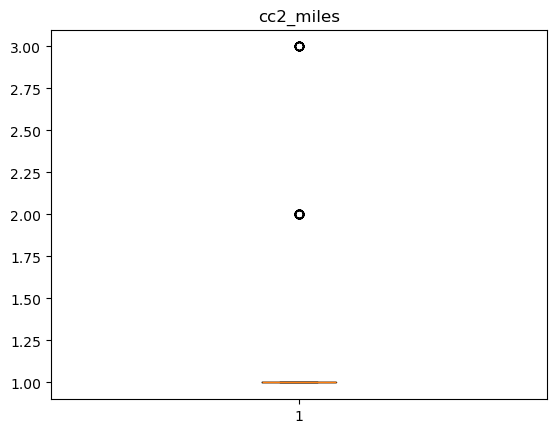

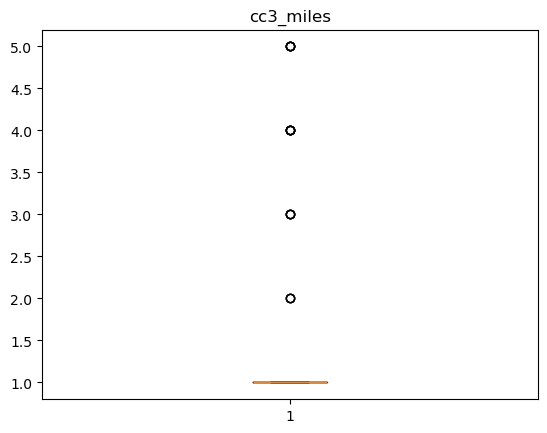

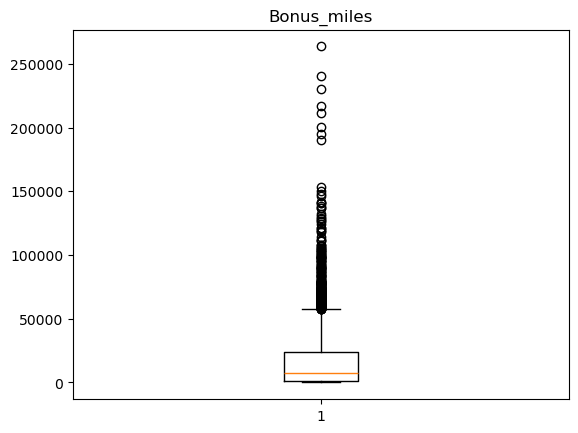

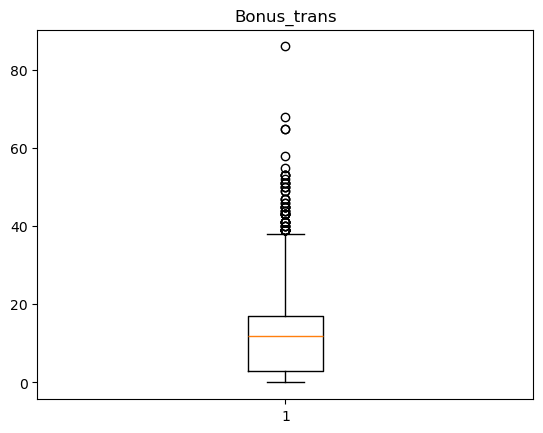

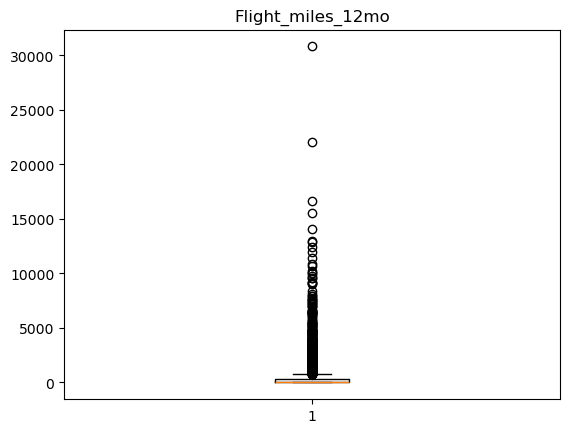

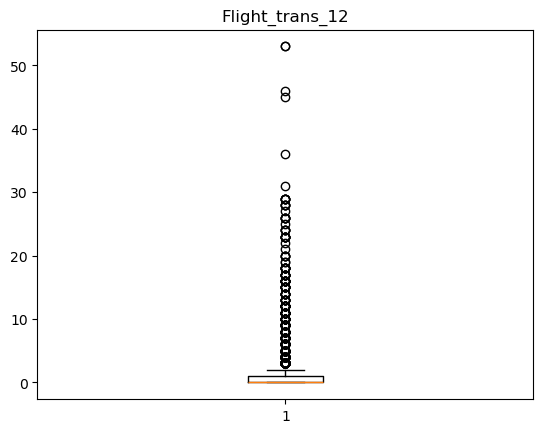

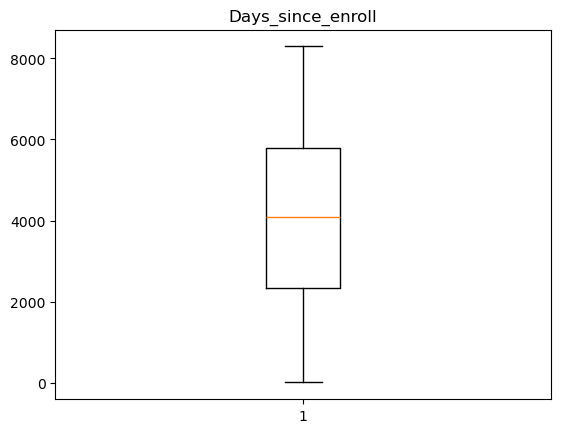

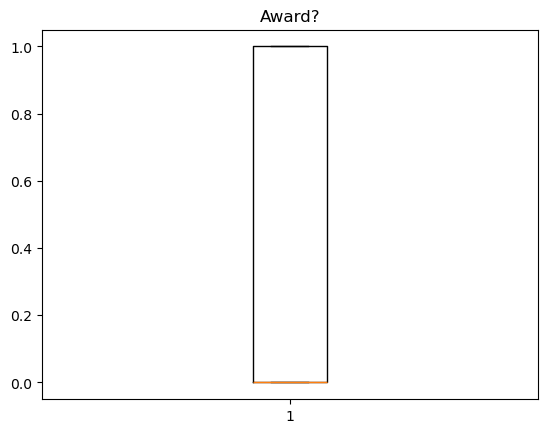

In [11]:
for i in df.select_dtypes(include='number').columns:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

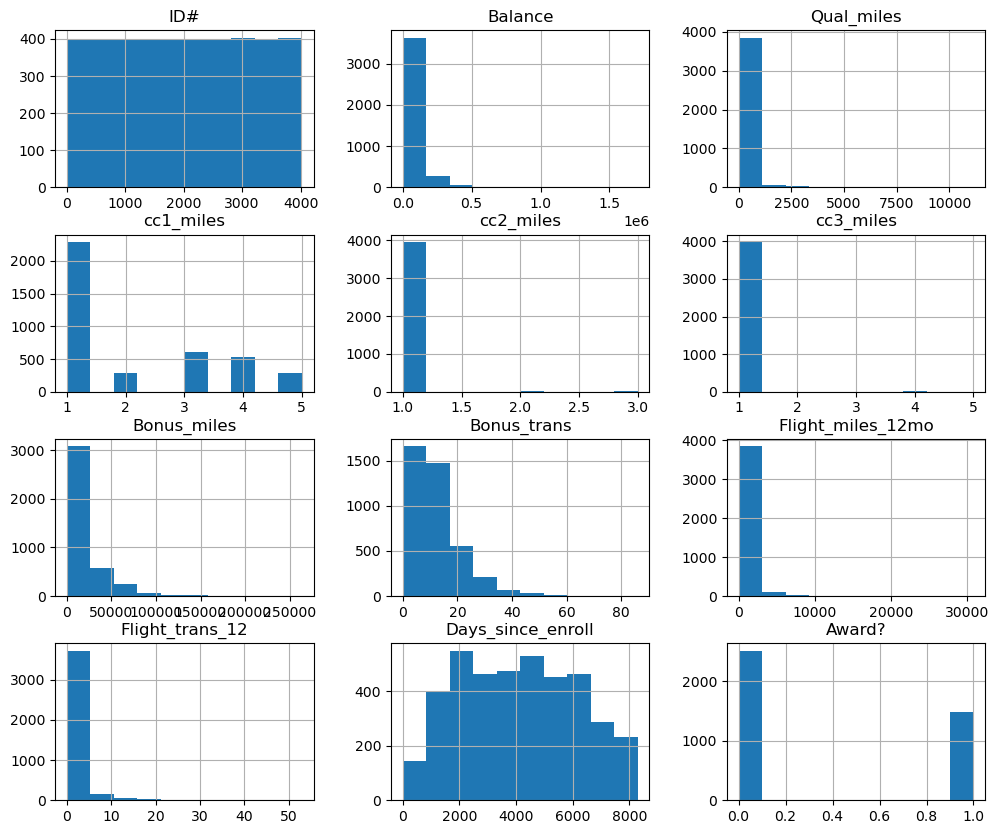

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.show()

Observation 
data set has 26 row and 5 column 
data type of all the column is categorical 
no null values are present 
no dupicate values are present 

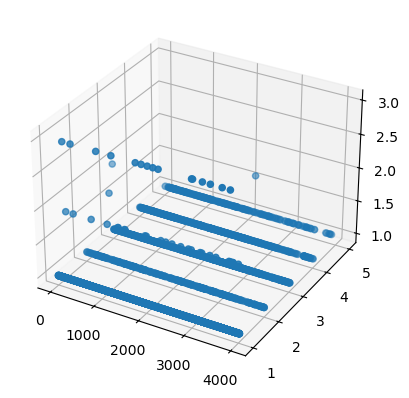

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df.iloc[:,0],df.iloc[:,3],df.iloc[:,4])
plt.show()

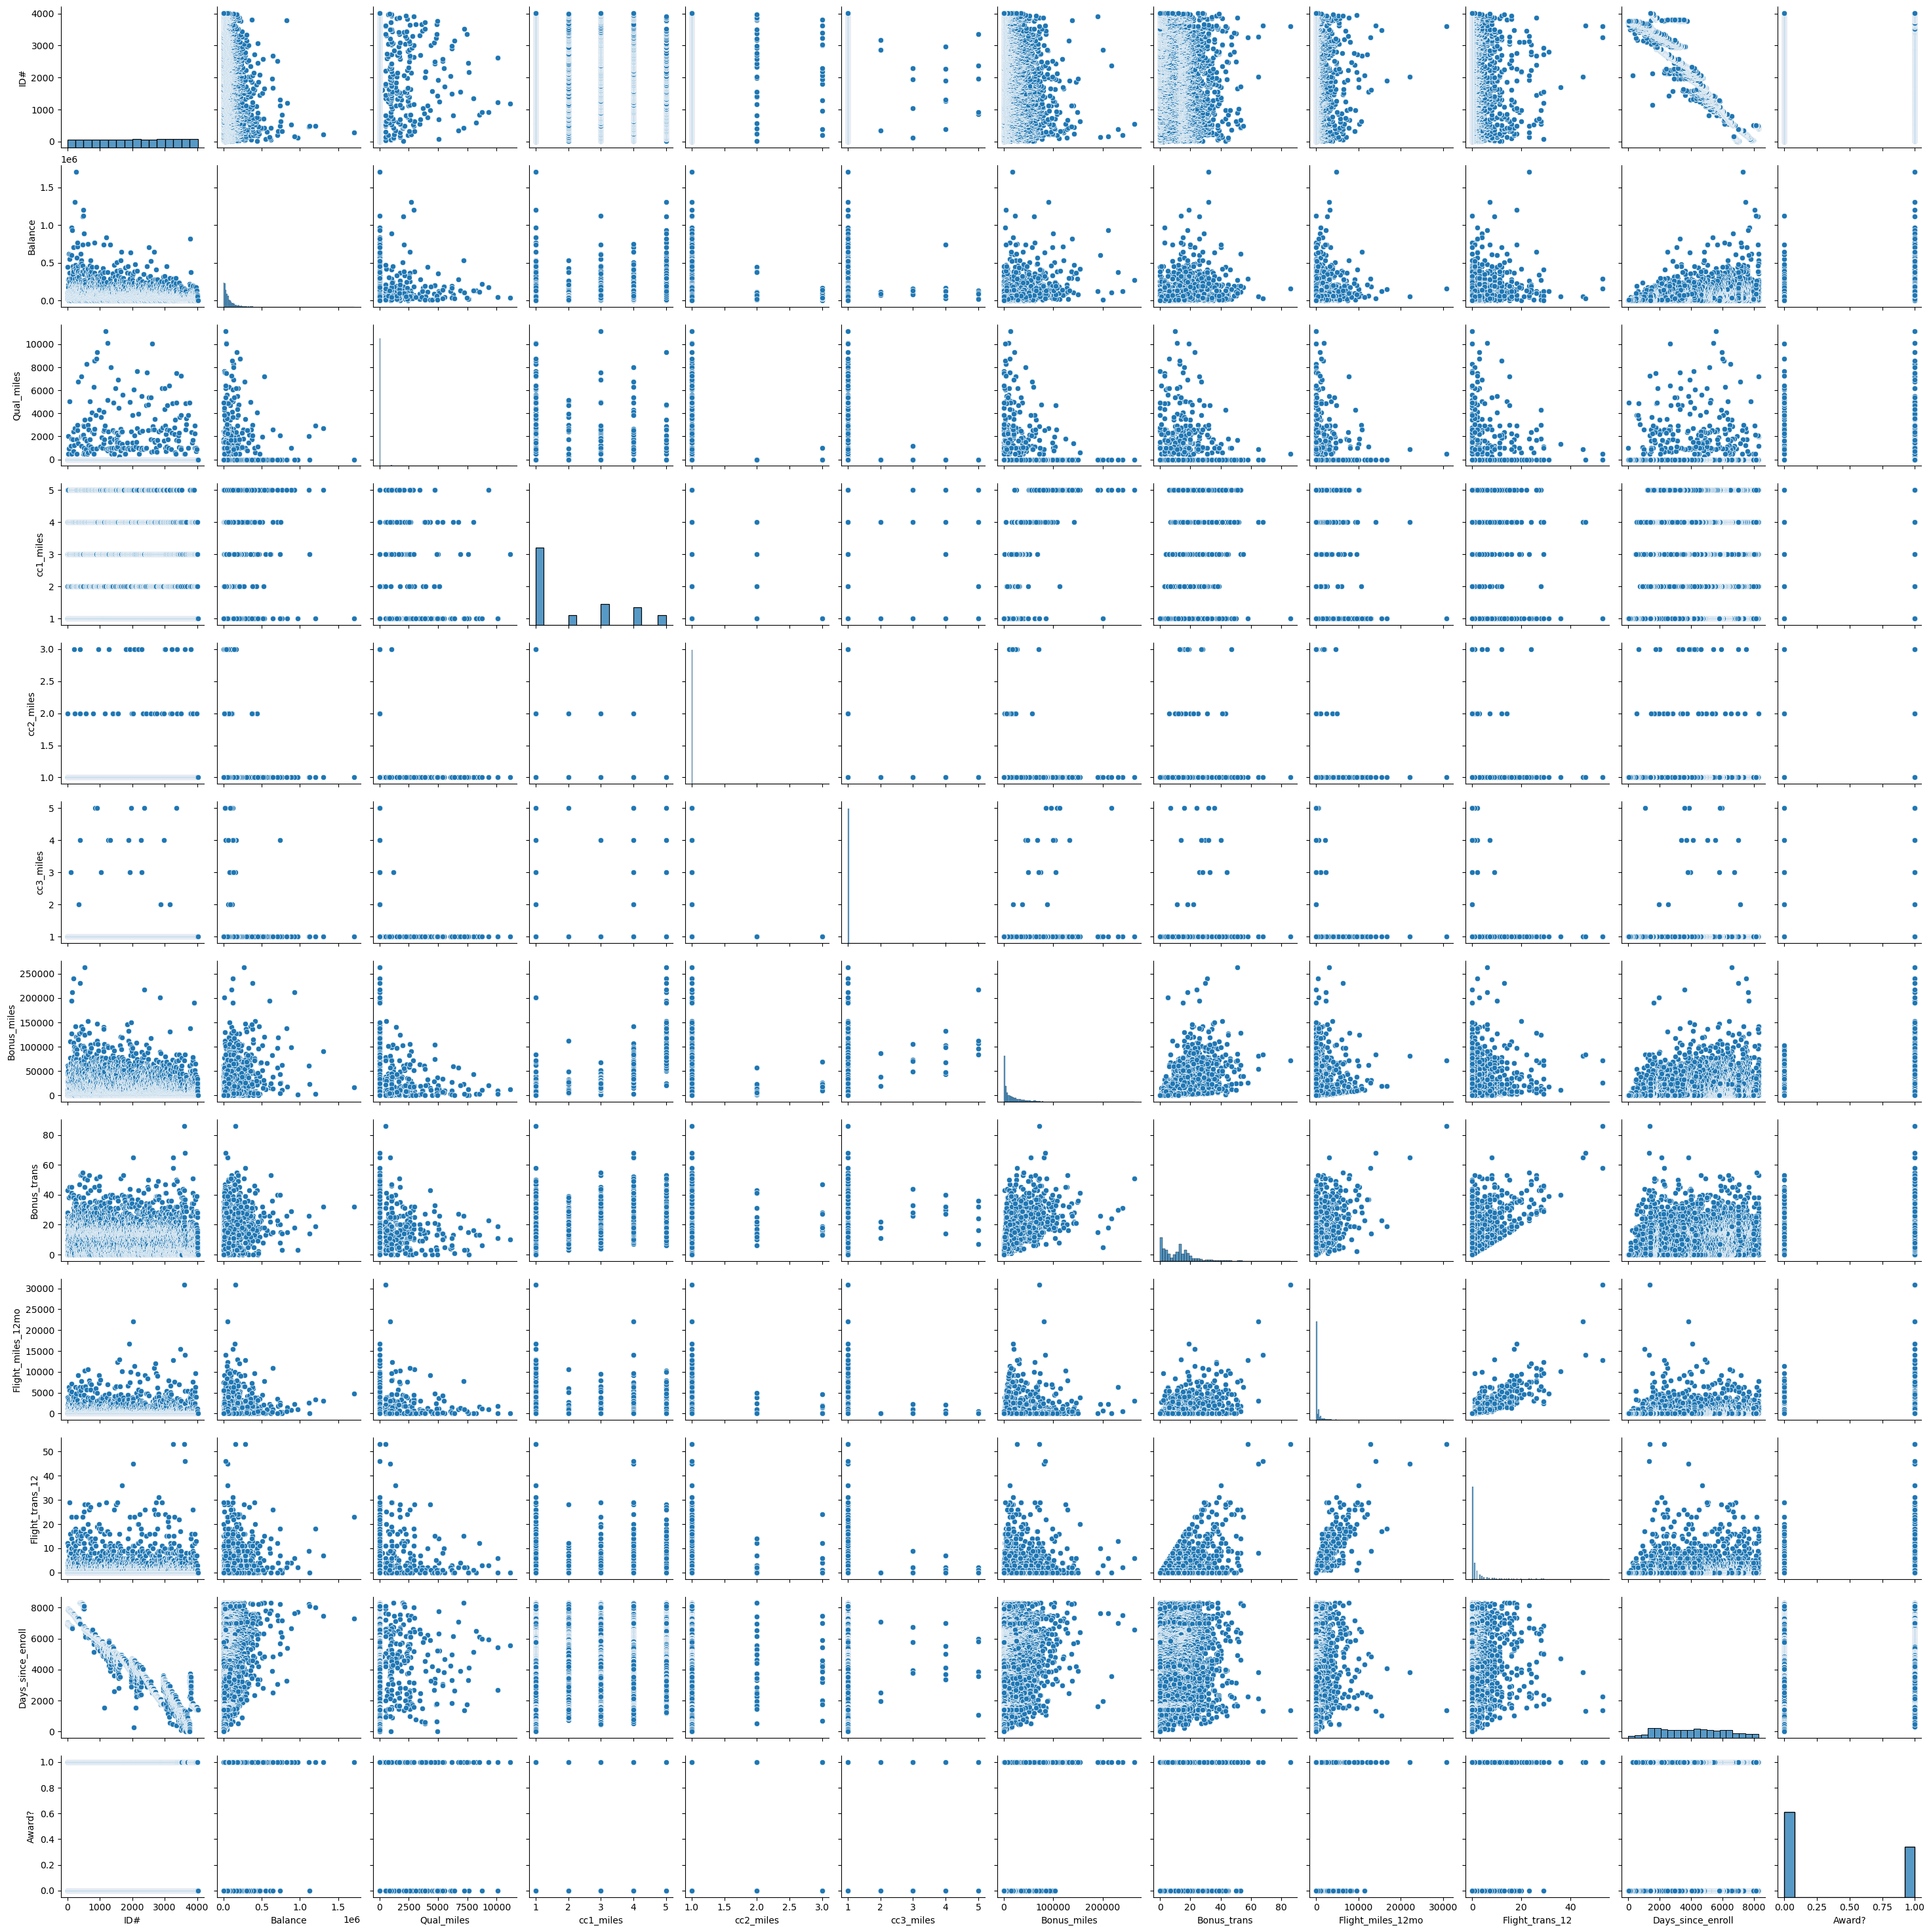

In [14]:
sns.pairplot(df)
plt.show()

In [15]:
# Using IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

Implementing Clustering Algorithms:
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [156]:
from sklearn.cluster import KMeans

In [20]:
km=KMeans(n_clusters=6,random_state=42)
km.fit(df)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

df['KMeans_Cluster'] = kmeans_labels

C:\Users\ACRE\AppData\Local\Temp\ipykernel_16060\2927431519.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['KMeans_Cluster'] = kmeans_labels


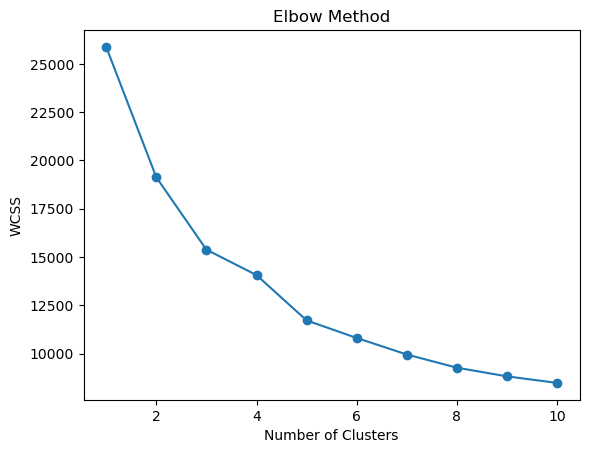

In [17]:
#elbow method
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [160]:
from sklearn.metrics import silhouette_score
silhouette_score(df,km.labels_)

0.5147223248155344

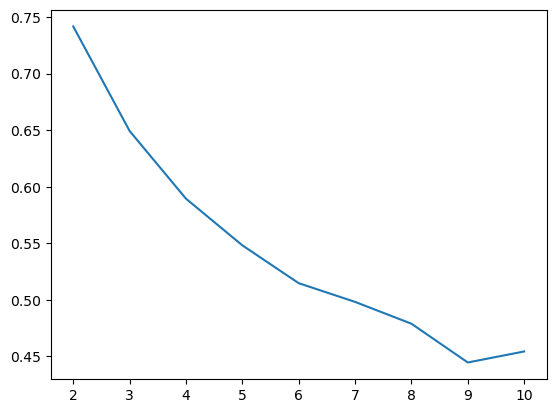

In [161]:
score=[]
for i in range(2,11):
  km=KMeans(n_clusters=i,random_state=42)
  km.fit(df)
  score.append(silhouette_score(df,km.labels_))

plt.plot(range(2,11),score)

In [162]:
from sklearn.cluster import DBSCAN 

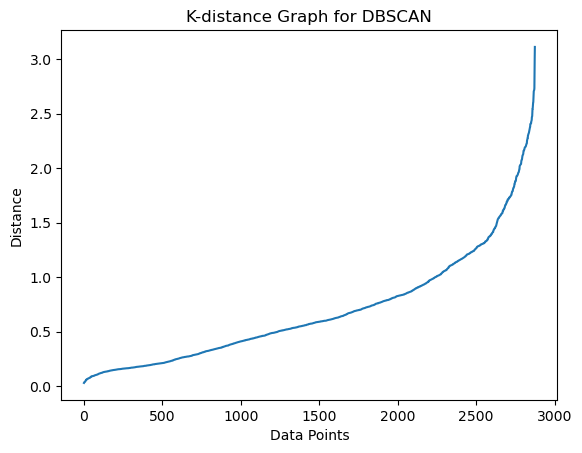

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("K-distance Graph for DBSCAN")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)  # justify from graph
db_labels = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = db_labels

C:\Users\ACRE\AppData\Local\Temp\ipykernel_16060\132066999.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DBSCAN_Cluster'] = db_labels


In [24]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette Score:", silhouette_score(df_scaled, kmeans_labels))

KMeans Silhouette Score: 0.30830264215957265


In [166]:
np.sort(distances,axis=0)

array([2.56124969e+01, 2.56124969e+01, 2.76767050e+01, ...,
       1.25392162e+05, 1.34603671e+05, 4.09459079e+05], shape=(3999,))

Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster.
    Write you insights in few comments

In [25]:
cluster_summary = df.groupby('KMeans_Cluster').mean()
print(cluster_summary)

                        ID#       Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                
0               2030.144044  65191.260388         0.0   2.047091        1.0   
1               2350.516423  28555.939781         0.0   1.086375        1.0   
2               1701.248276  73776.834483         0.0   3.144828        1.0   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                     1.0  14282.160665    11.725762         421.842105   
1                     1.0   2764.661800     5.359489           4.026156   
2                     1.0  24780.127586    16.022989           5.995402   

                Flight_trans_12  Days_since_enroll    Award?  DBSCAN_Cluster  
KMeans_Cluster                                                                
0                      1.301939        4100.620499  0.443213        -0

In [ ]:
Cluster 0 → High mileage + frequent flyers → Loyal premium customers
Cluster 1 → Low activity → Occasional travelers
Cluster 2 → Moderate balance + moderate flights → Regular customers
K-Means creates well-balanced clusters but assumes spherical shapes and equal density.

Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.
Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [ ]:
Interpretation:
Cluster -1 → Noise / Outliers (rare or abnormal customers)
Other clusters → Natural groupings based on density
DBSCAN is better at detecting:

Outliers (important in fraud/anomaly detection)
Irregular cluster shapes

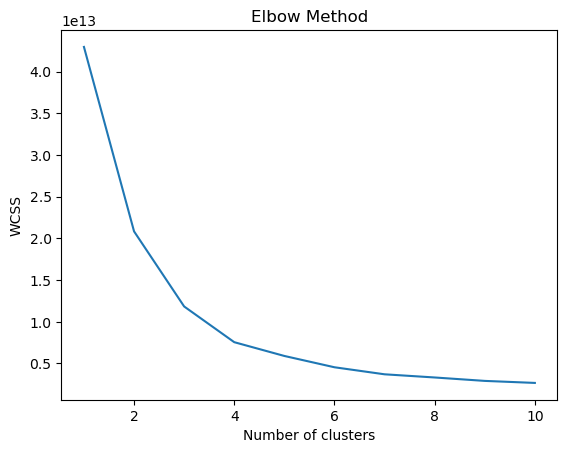

In [171]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)    #wcss(within cluster sum of squares)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

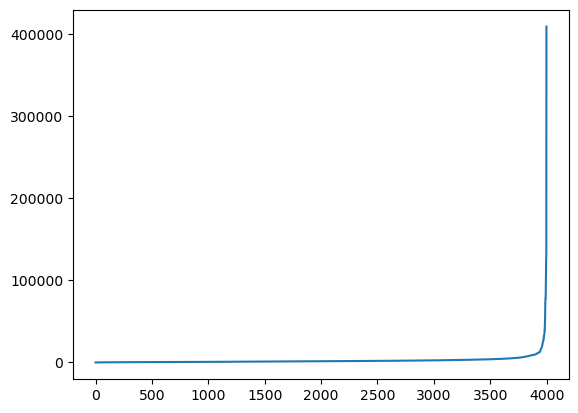

In [172]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
neigh= NearestNeighbors()
nbrs=neigh.fit(df)
distances,indices=nbrs.kneighbors(df)
distances=np.sort(distances,axis=0)
distances=distances[:,1]
plt.plot(distances)
plt.show()

In [ ]:
Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

In [26]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette Score:", silhouette_score(df_scaled, kmeans_labels))

KMeans Silhouette Score: 0.30830264215957265


In [31]:
from sklearn.metrics import silhouette_score

# Remove noise points (-1)
mask = db_labels != -1

# Check if enough clusters exist
if len(set(db_labels[mask])) > 1:
    score = silhouette_score(df_scaled[mask], db_labels[mask])
    print("DBSCAN Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated (only one cluster found")

DBSCAN Silhouette Score: -0.16252287104900257


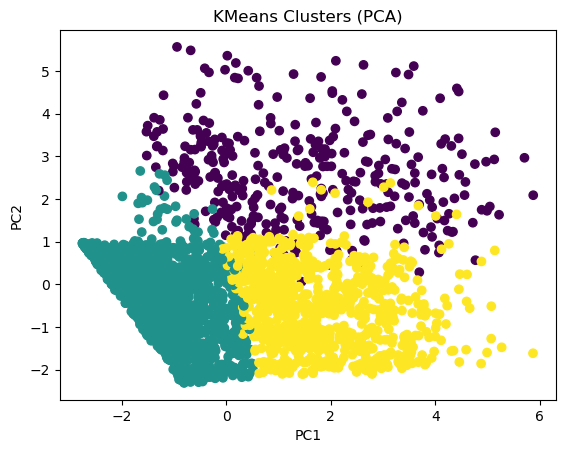

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.scatter(df_pca[:,0], df_pca[:,1], c=kmeans_labels)
plt.title("KMeans Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

DBSCAN silhouette score is calculated after removing noise points.
A lower score compared to K-Means may indicate:
presence of noise
non-spherical cluster shapes (where DBSCAN performs better)
DBSCAN is useful when clusters are irregularly shaped and contain outliers